In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold

sns.set_theme(style="whitegrid")

# **Q1**


1. A model is linear if it is linear in the coefficients/parameters. this does not mean neccessarily linear in the variables themselves.

2. For a dummy variable variable, the coefficient measures the difference between that category and the omitted reference group, holding other variables fixed. if you keep the intercept only one category must be dropped. Further more the intercept is the mean for hte reference group and the dummy coefficient is how much higher or lower the other group is relative to that reference group.

3. Linear regression can technically be used for classification, but it is usually not ideal because predicted values can fall below 0 or above 1, and the relationship between predictors and class probability is usually not truly linear. Logistic regression is better at classification than linear.

4. Overfitting can be found by very good performance on the training data but noticeably worse performance on validation or test data, unstable coefficients, and a model that becomes too sensitive to noise or small changes in the sample.

5. multicollinearity means one explanatory varaible is highly correlated with another, so it becomes hard to isolate each variable's seperate effect. Like in two stage least squares setting, if your endogenous regressor is highly collinear with other controls, the first stage has trouble seperating unique variation, which makes the second stage coefficient estimates unstable and not so accurate.

6. It is possible to include non linear relationships by adding transformation of x, such as x^2, x^3, logs or splines. The model can still be linear in coefficients even if the variables are transformed.

7. the slope coefficient gives the expected change in y from a one unit increase in x, holding other variables constant.

8. A train/test split uses one random split of the data into training and testing sets. It is simple and fast, but results can depend on the specific split. k fold cross validiation repeatdly splits the data into folds and avergages perfromance acrooss all of them. So it gives a more stable estimate of out of sample performance.

9. the value of k is usually chosen as a balance between computation and stability, such as common choices are like 5 or 10. Very common because it usually gives a reliable estiminate without being too compuationally expensive.

**Q2.1**

In [ ]:
q2 = pd.read_csv("Q1_clean.csv")
q2 = q2.rename(columns={
    "Neighbourhood ": "Neighbourhood",
    "Review Scores Rating": "Review_Scores_Rating"
})

q2.head()

,Price,Review_Scores_Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [ ]:
avg_table = q2.groupby("Neighbourhood")[["Price", "Review_Scores_Rating"]].mean().sort_values("Price", ascending=False)
avg_table

,Price,Review_Scores_Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


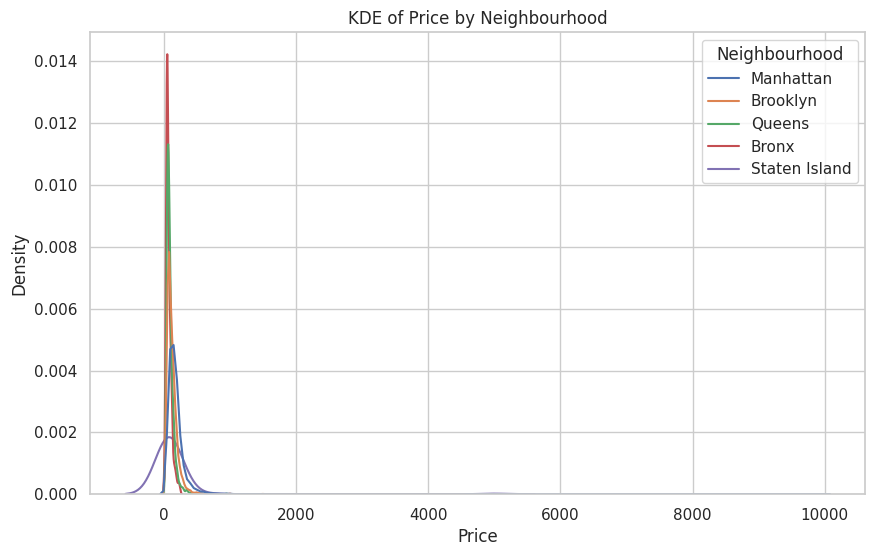

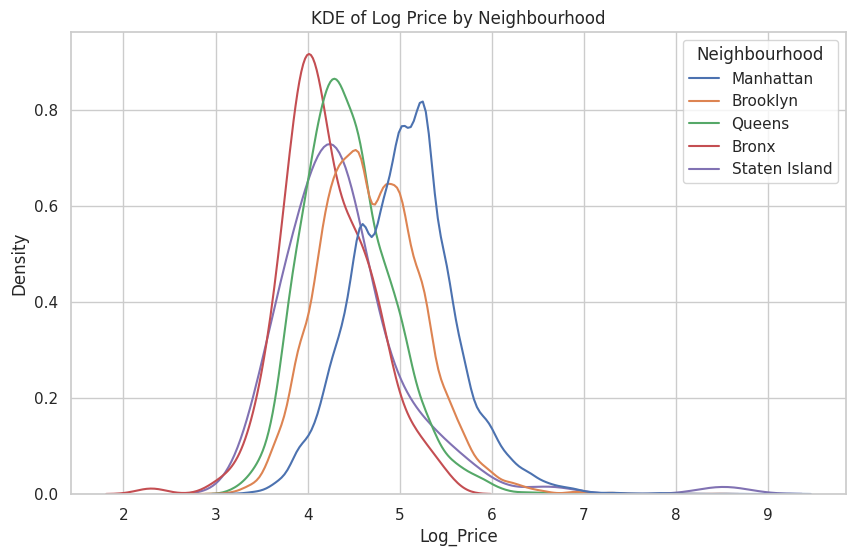

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=q2, x="Price", hue="Neighbourhood", common_norm=False)
plt.title("KDE of Price by Neighbourhood")
plt.show()

q2["Log_Price"] = np.log(q2["Price"])

plt.figure(figsize=(10,6))
sns.kdeplot(data=q2, x="Log_Price", hue="Neighbourhood", common_norm=False)
plt.title("KDE of Log Price by Neighbourhood")
plt.show()

Manhattan is the most expensive on average

In [ ]:
avg_table

,Price,Review_Scores_Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


**Q2.2**

In [ ]:
model_q22 = smf.ols("Price ~ C(Neighbourhood)", data=q2).fit()
print(model_q22.summary())
print(model_q22.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        04:42:34   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

Because the model includes an intercept, one neighborhood is ommitted as the reference group. Here the intercept is the mean price for the ommitted group and each neighborhood coefficient is the difference between that neighborhood's mean adn the refrence groups mean.

**Q2.3**

In [ ]:
model_q23 = smf.ols("Price ~ Review_Scores_Rating", data=q2).fit()
print(model_q23.summary())
print(model_q23.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        05:12:45   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.8784 

The slope on the review scores rating is about 1.02. this means that a 1 point increase in review is associated with about 1 dollar and 2 cents increase in nightly price, on average.

In [ ]:
model_q24 = smf.ols("Price ~ C(Neighbourhood) + Review_Scores_Rating", data=q2).fit()
print(model_q24.summary())
print(model_q24.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        05:14:07   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

Controlling for the neighborhood, the slope on review_scores_rating increases slightly from 1.02 to about 1.08. That means ratings still ahve a positve association with price, and that relationships become a little stronger once neighborhood differences are accounted for. The neighborhood coefficient now represents price differences across neighborhoods holding review score fixed.

In [ ]:
model_q25 = smf.ols(
    "Price ~ C(Neighbourhood) + C(Neighbourhood):Review_Scores_Rating",
    data=q2
).fit()

print(model_q25.summary())
print(model_q25.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:15:42   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

teh slopes are not exactly the same across neighborhoods. Brooklyn and amanhattan have fairly similar positive slopes, the bronx and queens have smaller positive slopes and staten island has a strange negative slope that is likely unstable because the sample size is smaller. So there is some evidence that the relationship between review score and price differs by neighborhood.

In [ ]:
def cv_rmse(formula, data, k=10, seed=1):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    rmses = []

    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]

        model = smf.ols(formula, data=train).fit()
        pred = model.predict(test)
        rmse = np.sqrt(np.mean((test["Price"] - pred) ** 2))
        rmses.append(rmse)

    return np.mean(rmses)

formulas = {
    "Part 3: Price ~ Review_Scores_Rating": "Price ~ Review_Scores_Rating",
    "Part 4: Price ~ C(Neighbourhood) + Review_Scores_Rating": "Price ~ C(Neighbourhood) + Review_Scores_Rating",
    "Part 5: Price ~ C(Neighbourhood) + C(Neighbourhood):Review_Scores_Rating": "Price ~ C(Neighbourhood) + C(Neighbourhood):Review_Scores_Rating"
}

for name, formula in formulas.items():
    print(name, "RMSE =", cv_rmse(formula, q2))

Part 3: Price ~ Review_Scores_Rating RMSE = 142.46290619252565
Part 4: Price ~ C(Neighbourhood) + Review_Scores_Rating RMSE = 138.67235104051787
Part 5: Price ~ C(Neighbourhood) + C(Neighbourhood):Review_Scores_Rating RMSE = 139.65893031050183


The model from part 4 preforms best in cross validation while the neighborhood only plus rating model ahs the lowest RMSE, while the interaaction model in part 5 does not improve enough to beat it. So part 4 seems like the best balance of fit and simple protrayal.

part 3: 142.46
part 4: 138.67
part 5: 139.66

# **Q3**

In [4]:
cars = pd.read_csv("cars_hw.csv")
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [ ]:
cars["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


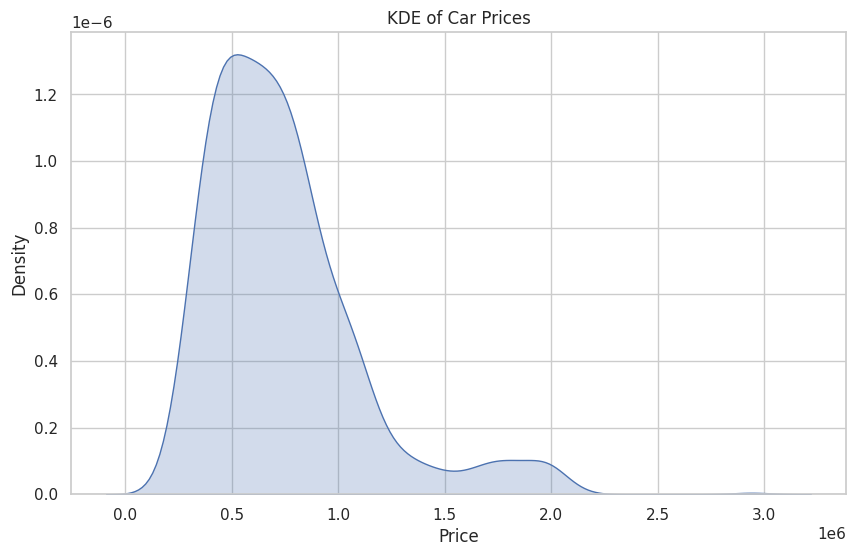

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=cars, x="Price", fill=True)
plt.title("KDE of Car Prices")
plt.show()

In [ ]:
body_summary = cars.groupby("Body_Type")["Price"].describe()
body_summary

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


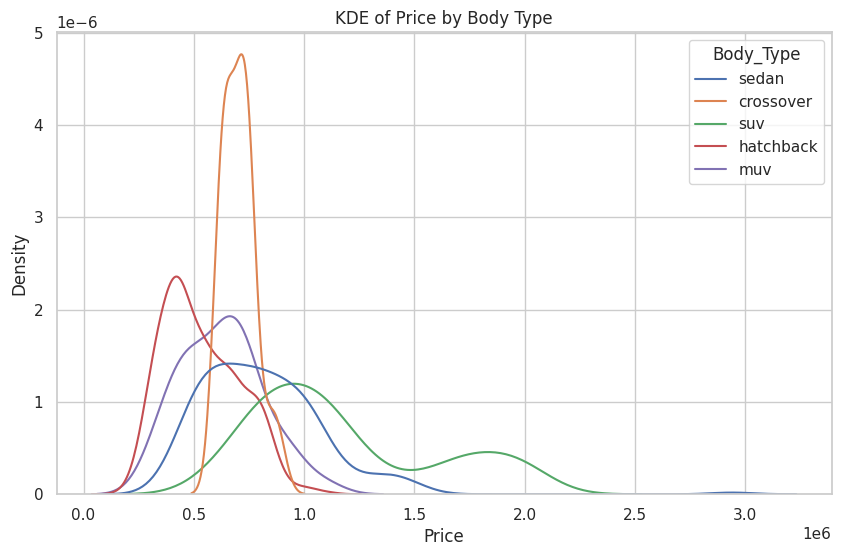

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=cars, x="Price", hue="Body_Type", common_norm=False)
plt.title("KDE of Price by Body Type")
plt.show()

SUVs are the most expensive on average which is then followed by sedans. SUVs also appear to have the most price variance with sedans showing substantial spread.

In [ ]:
cars.groupby("Body_Type")["Price"].mean().sort_values(ascending=False)


,Price
Body_Type,
suv,1.176495e+06
sedan,8.097841e+05
crossover,7.050952e+05
muv,6.264211e+05
hatchback,5.339773e+05


In [ ]:
cars.groupby("Body_Type")["Price"].std().sort_values(ascending=False)

,Price
Body_Type,
suv,417479.028217
sedan,286736.770092
muv,184093.488526
hatchback,173086.729837
crossover,72849.780207


largest variance is SUV and sedan

**Q3.2**

In [5]:
model_q32_linear = smf.ols("Price ~ Seating_Capacity", data=cars).fit()
print(model_q32_linear.summary())
print(model_q32_linear.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Fri, 27 Mar 2026   Prob (F-statistic):             0.0245
Time:                        02:52:10   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

The slope coeffieicient is about 59268. This means that each additional seat is associated with about a 59,268 rupee increase in price on average.

In [6]:
model_q32_cat = smf.ols("Price ~ C(Seating_Capacity)", data=cars).fit()
print(model_q32_cat.summary())
print(model_q32_cat.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           0.000267
Time:                        02:53:21   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [7]:
cars.groupby("Seating_Capacity")["Price"].mean()

,Price
Seating_Capacity,
4,1.880000e+05
5,7.344839e+05
6,1.644000e+06
7,9.239487e+05
8,4.598000e+05


The difference are not linear to the specific point. Prices increase from 4 to 5 to 6 seats but then the pattern does not continue smoothly for 7 and 8 seats so the treating seating capacity is as categorical which shows that the relationship is only roughly linear at best.

Q3.3

In [8]:
cars["Age"] = 2026 - cars["Make_Year"]
cars[["Make_Year", "Age"]].head()

,Make_Year,Age
0,2017,9
1,2016,10
2,2019,7
3,2017,9
4,2017,9


In [9]:
def poly_cv_rmse(data, max_degree=10, seed=1):
    kf = KFold(n_splits=10, shuffle=True, random_state=seed)
    results = []

    for d in range(1, max_degree + 1):
        rmses = []
        formula = "Price ~ " + " + ".join([f"I(Age**{p})" for p in range(1, d + 1)])

        for train_idx, test_idx in kf.split(data):
            train = data.iloc[train_idx]
            test = data.iloc[test_idx]

            model = smf.ols(formula, data=train).fit()
            pred = model.predict(test)
            rmse = np.sqrt(np.mean((test["Price"] - pred) ** 2))
            rmses.append(rmse)

        results.append([d, np.mean(rmses)])

    return pd.DataFrame(results, columns=["degree", "cv_rmse"])

cv_results = poly_cv_rmse(cars, max_degree=10)
cv_results

,degree,cv_rmse
0,1,310378.396887
1,2,310457.787568
2,3,309616.738130
3,4,308930.145217
4,5,307509.787490
5,6,307682.560340
6,7,306600.440545
7,8,305047.474062
8,9,304339.367517
9,10,304510.067337


In [11]:
best_degree = cv_results.loc[cv_results["cv_rmse"].idxmin(), "degree"]
best_degree

np.int64(9)

usign 10 fold cross validation, the best model among degrees 1 thorugh 10 uses 9 poewrs of Age. It has the lowest avg RMSE.

**Q3.4**

In [12]:
best_degree = 9
formula_best = "Price ~ " + " + ".join([f"I(Age**{p})" for p in range(1, best_degree + 1)])
best_model = smf.ols(formula_best, data=cars).fit()
print(best_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     55.24
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           5.55e-74
Time:                        03:04:27   Log-Likelihood:                -13707.
No. Observations:                 976   AIC:                         2.743e+04
Df Residuals:                     967   BIC:                         2.748e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    1.129e+09   3.69e+08      3.064      

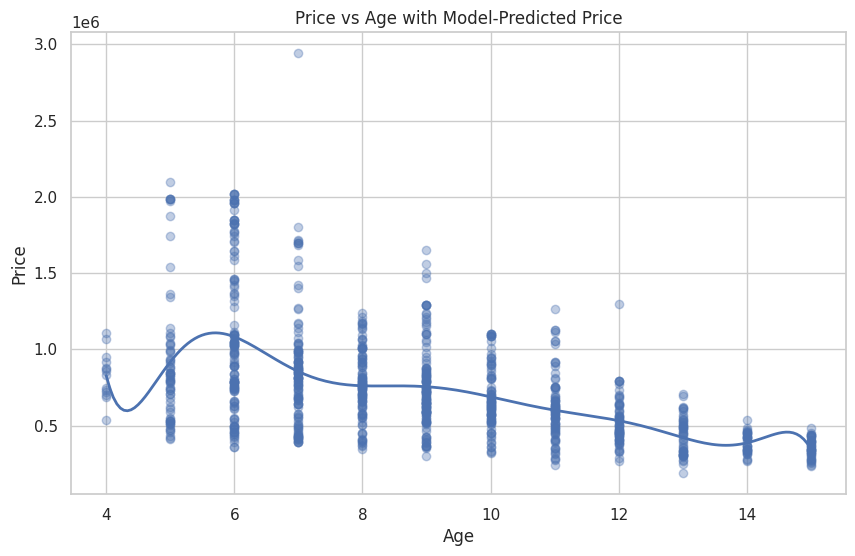

In [13]:
age_grid = pd.DataFrame({"Age": np.linspace(cars["Age"].min(), cars["Age"].max(), 200)})
age_grid["predicted_price"] = best_model.predict(age_grid)

plt.figure(figsize=(10,6))
plt.scatter(cars["Age"], cars["Price"], alpha=0.35)
plt.plot(age_grid["Age"], age_grid["predicted_price"], linewidth=2)
plt.title("Price vs Age with Model-Predicted Price")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()


The fitted curve captures the general downward relationship between car price and age but there is still a lot of scatter around the curve so the model picks up the main trend but it does not fully explain the vast varaition in prices. This suggest age matters but other features also affect price a great amount.

# **Q4**

In [15]:
heart = pd.read_csv("heart_hw.csv")
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [16]:
# proportions
control = heart[heart["transplant"] == "control"]["y"].mean()
treatment = heart[heart["transplant"] == "treatment"]["y"].mean()

ATE = treatment - control

control, treatment, ATE

(np.float64(0.11764705882352941),
 np.float64(0.34782608695652173),
 np.float64(0.23017902813299232))

Control = 0.117
Treat = 0.348
ATE = 0.230

receiving a transplant increases the probalbility of surviving three years by about 23.0 percent on average.

In [17]:
model_q42 = smf.ols("y ~ C(transplant)", data=heart).fit()
print(model_q42.params)

Intercept                     0.117647
C(transplant)[T.treatment]    0.230179
dtype: float64


Intercept = 0.1176 ---> survival probabliity for control group
Transplant coeffiecient = 0.230 ----> exactly the ATE

In [18]:
model_q43 = smf.ols("y ~ C(transplant) + age", data=heart).fit()
print(model_q43.summary())
print(model_q43.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           0.000357
Time:                        03:24:18   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

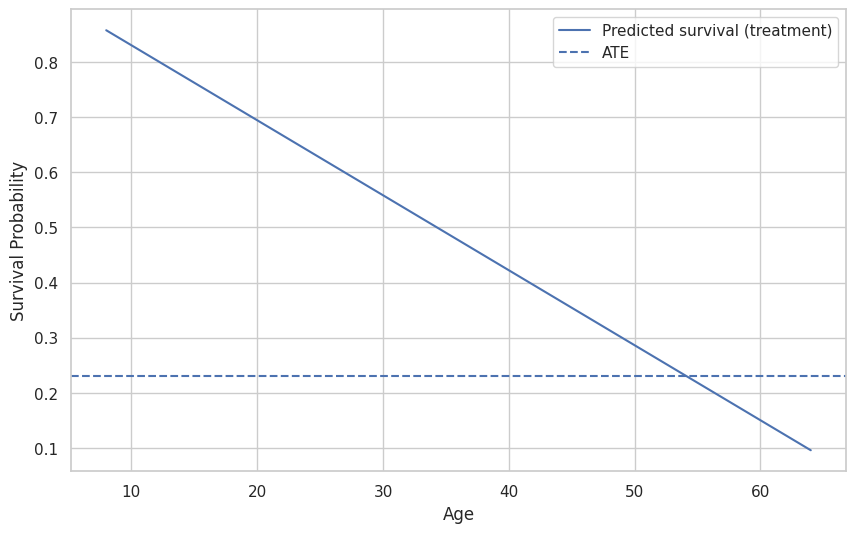

In [19]:
age_grid = pd.DataFrame({
    "age": np.linspace(heart["age"].min(), heart["age"].max(), 200),
    "transplant": "treatment"
})

age_grid["pred"] = model_q43.predict(age_grid)

plt.figure(figsize=(10,6))
plt.plot(age_grid["age"], age_grid["pred"], label="Predicted survival (treatment)")
plt.axhline(ATE, linestyle="--", label="ATE")
plt.xlabel("Age")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

After controlling for age the transplant coefficient decreases slightly showing that part of the original difference in suruvival rates was due to age differences between groups. The intercept shows the predicted survivival probabliity for a control patient at age 0. It also shows survival decrease as age increases.

So typically transplants help more for some ages than others to provide safe logenvity.

In [20]:
def cv_rmse_y(formula, data, k=10, seed=1):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    rmses = []

    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]

        model = smf.ols(formula, data=train).fit()
        pred = model.predict(test)
        rmse = np.sqrt(np.mean((test["y"] - pred) ** 2))
        rmses.append(rmse)

    return np.mean(rmses)

models = {
    "Model 1": "y ~ C(transplant)",
    "Model 2": "y ~ C(transplant) + age",
    "Model 3": "y ~ C(transplant)*age"
}

for name, f in models.items():
    print(name, cv_rmse_y(f, heart))

Model 1 0.43712414924209
Model 2 0.4209998366059898
Model 3 0.42010824697341675


Model 1 has the highest RMSE (worst performance).
Model 2 and Model 3 both substantially improve predictive accuracy.
Model 3 has the lowest RMSE, but the improvement over Model 2 is very small.


4.6

The model is based on observational data so it may be baised and not reflect true causual relation also it may reinforce existing inequalities in who recieves transplants. Such as age could effect unfraily disadvantage older patients. Using a model for life and death decision risks oversimplifying ethical choices.

This should not be used to decide transplant placement.